## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☑ |
| Dataset descrito, com fonte, atributos e restrições | ☑ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☑ |
| Análise exploratória objetiva, conectada à modelagem | ☑ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☑ |
| Prevenção de vazamento de dados | ☑ |
| Tratamentos de dados justificados | ☑ |
| Pipeline ou sequência reprodutível de pré-processamento | ☑ |
| Modelo baseline definido | ☑ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☑ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☑ |
| Avaliação com métricas coerentes com o problema | ☑ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☑ |
| Código limpo, organizado e executável do início ao fim | ☑ |
| Conclusão conectada ao objetivo inicial | ☑ |



# MVP — Machine Learning & Analytics

**Nome:** _Carine Maria Barros de Resende_  
**Matrícula:** _4052026000192_  
**Data:** _07/06/2026_  
**Dataset:** _Default of Credit Card Clients_  
**Fonte:** https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients  
**Tipo de problema:** _Classificação_  



# 1. Definição do problema

## 1.1 Descrição do problema

A concessão de crédito é uma das atividades mais importantes das instituições financeiras. Entretanto, a possibilidade de inadimplência dos clientes representa um dos principais riscos para bancos e empresas do setor financeiro, podendo gerar perdas significativas e comprometer a rentabilidade das operações.

Nesse contexto, técnicas de Machine Learning podem ser utilizadas para identificar padrões históricos de comportamento dos clientes e auxiliar na previsão da inadimplência futura. Modelos preditivos permitem apoiar decisões relacionadas à concessão de crédito, definição de limites e gerenciamento de riscos.

## 1.2 Objetivo do MVP

O objetivo deste trabalho é desenvolver e avaliar modelos de Machine Learning capazes de prever se um cliente de cartão de crédito apresentará inadimplência no mês seguinte, utilizando informações cadastrais, financeiras e históricas de pagamento.

## 1.3 Tipo de problema

Este problema é caracterizado como uma tarefa de classificação supervisionada binária, uma vez que o modelo deverá prever uma variável-alvo com duas possíveis classes:

0: Cliente adimplente (não ficará inadimplente);

1: Cliente inadimplente (ficará inadimplente).

O problema pode ser tratado utilizando Machine Learning porque existe um conjunto histórico de observações contendo atributos dos clientes e o resultado observado (inadimplência ou não), permitindo que algoritmos aprendam padrões e realizem previsões para novos casos.

## 1.4 Premissas, hipóteses e critérios de sucesso

### Premissas

- Os dados históricos representam adequadamente o comportamento dos clientes.

- As variáveis disponíveis possuem relação com o risco de inadimplência.

- O dataset utilizado é suficiente para treinamento e avaliação dos modelos.

- Os resultados obtidos refletem apenas o comportamento observado na base analisada, não podendo ser generalizados para todas as instituições financeiras sem validação adicional.


### Hipóteses

- Clientes com histórico de atrasos em pagamentos apresentam maior probabilidade de inadimplência futura.

- O comportamento financeiro passado é um bom indicador do comportamento financeiro futuro.

- Variáveis relacionadas ao limite de crédito, valores de fatura e histórico de pagamentos possuem capacidade preditiva para o problema estudado.


### Critérios de Sucesso

O MVP será considerado bem-sucedido caso os modelos desenvolvidos apresentem desempenho superior ao modelo baseline e sejam capazes de identificar clientes inadimplentes com métricas adequadas para o problema de classificação, especialmente Recall, F1-Score e ROC-AUC.

Além disso, espera-se que o modelo demonstre capacidade de generalização ao ser avaliado em dados não vistos durante o treinamento.


### Restrições

Este MVP possui caráter acadêmico e exploratório, não devendo ser utilizado diretamente para tomada de decisões reais de crédito sem validações complementares. Além disso, a base utilizada contém dados de uma instituição financeira específica e de um período determinado, o que pode limitar a generalização dos resultados.

# 2. Ambiente, bibliotecas e reprodutibilidade

Este projeto foi desenvolvido utilizando a linguagem Python no ambiente Google Colab. Foram utilizadas bibliotecas para manipulação de dados, visualização gráfica, pré-processamento, treinamento e avaliação de modelos de Machine Learning.

Para garantir a reprodutibilidade dos resultados, foi definida uma seed fixa (42), utilizada em todas as etapas que envolvem processos aleatórios, como divisão dos dados em treino e teste e treinamento dos modelos.

Como o volume de dados e os algoritmos utilizados apresentam baixo custo computacional, não foi necessária a utilização de GPU. Todos os experimentos foram executados utilizando os recursos padrão disponibilizados pelo Google Colab.

A utilização de uma seed fixa permite que outros usuários reproduzam os resultados obtidos neste trabalho de forma consistente.

In [1]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier


from sklearn.linear_model import LogisticRegression


from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

from scipy.stats import randint

warnings.filterwarnings("ignore")

# ==================================================
# Reprodutibilidade
# ==================================================

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)

import sklearn

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-Learn:", sklearn.__version__)

Python: 3.12.13
Seed: 42
Pandas: 2.2.2
NumPy: 2.0.2
Scikit-Learn: 1.6.1


## 2.1 Dependências adicionais

Não foi necessária a instalação de bibliotecas adicionais além das bibliotecas padrão utilizadas em projetos de Ciência de Dados e Machine Learning. Dessa forma, reduz-se o risco de incompatibilidades e facilita-se a reprodução dos experimentos por terceiros.

## 2.2 Funções auxiliares

Para melhorar a organização e a reutilização do código, foram definidas funções auxiliares para cálculo de métricas e apresentação dos resultados. Essa abordagem reduz a repetição de código, facilita a comparação entre modelos e contribui para a legibilidade do notebook.

In [2]:
def evaluate_classification(y_true, y_pred, proba=None):
    """
    Calcula métricas básicas para classificação.
    """

    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan

    return results


def show_results_table(results_dict):
    """
    Exibe resultados em formato de tabela.
    """

    return pd.DataFrame(results_dict).T

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O dataset utilizado neste projeto é o Default of Credit Card Clients, disponibilizado publicamente pelo UCI Machine Learning Repository.

Fonte oficial:
https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

A base contém informações demográficas, financeiras e históricas de pagamento de 30.000 clientes de cartão de crédito de uma instituição financeira em Taiwan. O objetivo é prever se o cliente apresentará inadimplência no mês seguinte.

A escolha deste dataset foi motivada por sua relevância para o setor financeiro, ampla utilização em pesquisas acadêmicas e adequação ao problema de classificação supervisionada proposto neste MVP.

Como os dados são públicos e anonimizados, não há exposição de informações pessoais identificáveis. Dessa forma, não foram identificadas restrições relacionadas à privacidade ou confidencialidade dos dados. Além disso, o dataset está disponível para fins educacionais e de pesquisa, permitindo sua utilização neste trabalho acadêmico.

O carregamento dos dados será realizado diretamente a partir do repositório público da UCI, garantindo a reprodutibilidade do experimento sem necessidade de upload manual de arquivos.

## 3.2 Carga dos dados



In [3]:
# ==================================================
# 3.2 Carga dos dados
# ==================================================

# Instalação da biblioteca para acesso ao dataset da UCI
!pip install -q ucimlrepo

from ucimlrepo import fetch_ucirepo

# Carregamento do dataset
credit_default = fetch_ucirepo(id=350)

# Variáveis preditoras
X = credit_default.data.features

# Variável-alvo
y = credit_default.data.targets

# DataFrame completo
df = pd.concat([X, y], axis=1)

print(f"Formato do dataset: {df.shape}")

display(df.head())

print("\nDistribuição da variável-alvo:")
display(df["Y"].value_counts())

target_percent = (
    df["Y"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("Percentual (%)")
)

print("\nDistribuição percentual:")
display(target_percent)

print("\nColunas do dataset:")
display(df.columns)

Formato do dataset: (30000, 24)


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0



Distribuição da variável-alvo:


,count
Y,
0,23364
1,6636



Distribuição percentual:


,Percentual (%)
Y,
0,77.88
1,22.12



Colunas do dataset:


Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21',
       'X22', 'X23', 'Y'],
      dtype='object')

## 3.3 Visão geral do dataset

Antes da etapa de modelagem, é importante compreender a estrutura da base de dados. Nesta seção serão analisadas características gerais do dataset, incluindo quantidade de registros, tipos de variáveis, presença de valores ausentes, registros duplicados e características da variável-alvo.

Essa análise inicial permite identificar possíveis problemas de qualidade dos dados e direcionar as etapas de preparação e modelagem.


In [4]:
# ==================================================
# 3.3 Visão geral do dataset
# ==================================================

print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

print("\nTipos de dados:")
display(df.dtypes.to_frame("Tipo"))

print("\nValores ausentes:")
display(df.isnull().sum().to_frame("Quantidade"))

print("\nRegistros duplicados:")
print(df.duplicated().sum())

print("\nInformações gerais:")
df.info()

print("\nEstatísticas descritivas:")
display(df.describe().T)

print("\nAmostra aleatória:")
display(df.sample(5, random_state=SEED))

Quantidade de linhas: 30000
Quantidade de colunas: 24

Tipos de dados:


,Tipo
X1,int64
X2,int64
X3,int64
X4,int64
X5,int64
X6,int64
X7,int64
X8,int64
X9,int64
X10,int64



Valores ausentes:


,Quantidade
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
X9,0
X10,0



Registros duplicados:
35

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22 

,count,mean,std,min,25%,50%,75%,max
X1,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
X2,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
X3,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
X4,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
X5,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
X6,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
X7,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
X8,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
X9,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
X10,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0



Amostra aleatória:


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
2308,30000,1,2,2,25,0,0,0,0,0,...,12580,13716,14828,1500,2000,1500,1500,1500,2000,0
22404,150000,2,1,2,26,0,0,0,0,0,...,101581,77741,77264,4486,4235,3161,2647,2669,2669,0
23397,70000,2,3,1,32,0,0,0,0,0,...,69753,70111,70212,2431,3112,3000,2438,2500,2554,0
25058,130000,1,3,2,49,0,0,0,0,0,...,16898,11236,6944,1610,1808,7014,27,7011,4408,0
2664,50000,2,2,2,36,0,0,0,0,0,...,19574,20295,19439,2000,1500,1000,1800,0,1000,1


## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---------|---------|---------|---------|---------|
| X1 | Numérica | Limite de crédito concedido | Sim | Variável financeira relevante |
| X2 | Categórica | Sexo do cliente | Sim | Perfil demográfico |
| X3 | Categórica | Escolaridade | Sim | Perfil socioeconômico |
| X4 | Categórica | Estado civil | Sim | Perfil demográfico |
| X5 | Numérica | Idade do cliente | Sim | Perfil do cliente |
| X6 a X11 | Numérica | Histórico de atrasos de pagamento | Sim | Forte indicador de risco |
| X12 a X17 | Numérica | Valores das faturas mensais | Sim | Comportamento financeiro |
| X18 a X23 | Numérica | Valores pagos mensalmente | Sim | Comportamento financeiro |
| Y | Alvo | Inadimplência no mês seguinte | Alvo | 0 = Não, 1 = Sim |

# 4. Análise exploratória dos dados

## 4.1 Objetivos da análise exploratória

A Análise Exploratória dos Dados (Exploratory Data Analysis – EDA) tem como objetivo compreender as principais características do conjunto de dados antes da etapa de modelagem. Nesta fase são investigadas a distribuição da variável-alvo, a qualidade dos dados, possíveis inconsistências, a distribuição das variáveis, a relação entre os atributos e a ocorrência de inadimplência.

Os resultados desta análise servirão de base para as decisões de preparação dos dados e para a seleção dos modelos de Machine Learning utilizados nas etapas seguintes.

## 4.2 Configuração da análise

In [5]:
# ==================================================
# 4.2 Configuração da análise
# ==================================================

TARGET = "Y"

# Variáveis categóricas (codificadas numericamente)
categorical_cols = ["X2", "X3", "X4"]

# Variáveis numéricas
numeric_cols = [
    col for col in df.columns
    if col not in categorical_cols + [TARGET]
]

print(f"Variável-alvo: {TARGET}")
print(f"Número de variáveis numéricas: {len(numeric_cols)}")
print(f"Número de variáveis categóricas: {len(categorical_cols)}")

print("\nVariáveis categóricas:")
print(categorical_cols)

print("\nVariáveis numéricas:")
print(numeric_cols)

Variável-alvo: Y
Número de variáveis numéricas: 20
Número de variáveis categóricas: 3

Variáveis categóricas:
['X2', 'X3', 'X4']

Variáveis numéricas:
['X1', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23']


## 4.3 Distribuição da variável-alvo

A análise da variável-alvo permite verificar a proporção de clientes adimplentes e inadimplentes presente na base de dados. Essa informação é importante porque problemas de classificação com classes desbalanceadas podem influenciar o treinamento dos modelos e a escolha das métricas de avaliação.

Nesta etapa são apresentadas a distribuição absoluta e relativa das classes, bem como uma representação gráfica que facilita a visualização do balanceamento do conjunto de dados.

,Quantidade,Percentual (%)
Adimplente,23364,77.88
Inadimplente,6636,22.12


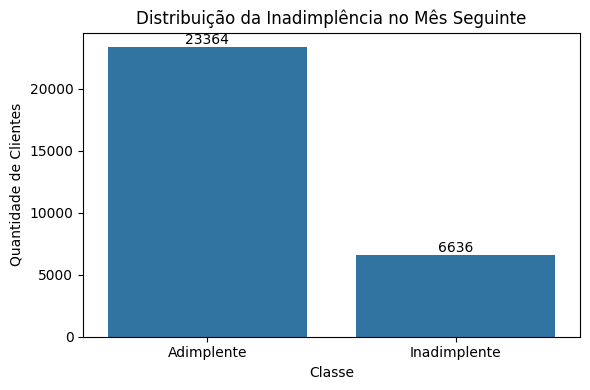

In [6]:
# ==================================================
# 4.3 Distribuição da variável-alvo
# ==================================================

# Frequência absoluta
target_counts = df[TARGET].value_counts().sort_index()

# Frequência relativa
target_percent = (
    df[TARGET]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# Tabela resumo
target_distribution = pd.DataFrame({
    "Quantidade": target_counts,
    "Percentual (%)": target_percent
})

target_distribution.index = [
    "Adimplente",
    "Inadimplente"
]

display(target_distribution)

# Gráfico
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x=TARGET
)

ax.bar_label(ax.containers[0])

plt.title("Distribuição da Inadimplência no Mês Seguinte")
plt.xlabel("Classe")
plt.ylabel("Quantidade de Clientes")

plt.xticks(
    ticks=[0, 1],
    labels=["Adimplente", "Inadimplente"]
)

plt.tight_layout()
plt.show()

### Interpretação

Observa-se predominância da classe correspondente aos clientes adimplentes, representando aproximadamente 78% das observações. Os clientes inadimplentes correspondem a cerca de 22% da base de dados.

Embora exista desbalanceamento entre as classes, ele não é suficientemente acentuado para impedir o treinamento inicial dos modelos sem a aplicação de técnicas de balanceamento. Entretanto, durante a etapa de avaliação serão priorizadas métricas como Recall, F1-Score e ROC-AUC, que são mais adequadas para problemas de classificação com distribuição desigual das classes.

## 4.4 Análise das variáveis categóricas

As variáveis categóricas representam características demográficas dos clientes, como sexo, escolaridade e estado civil. Nesta etapa busca-se compreender a distribuição dessas categorias e verificar possíveis diferenças no comportamento da inadimplência entre os grupos.

Embora essa análise seja essencialmente descritiva e não permita estabelecer relações de causalidade, ela fornece evidências importantes sobre padrões presentes na base de dados que poderão contribuir para o desempenho dos modelos de Machine Learning.

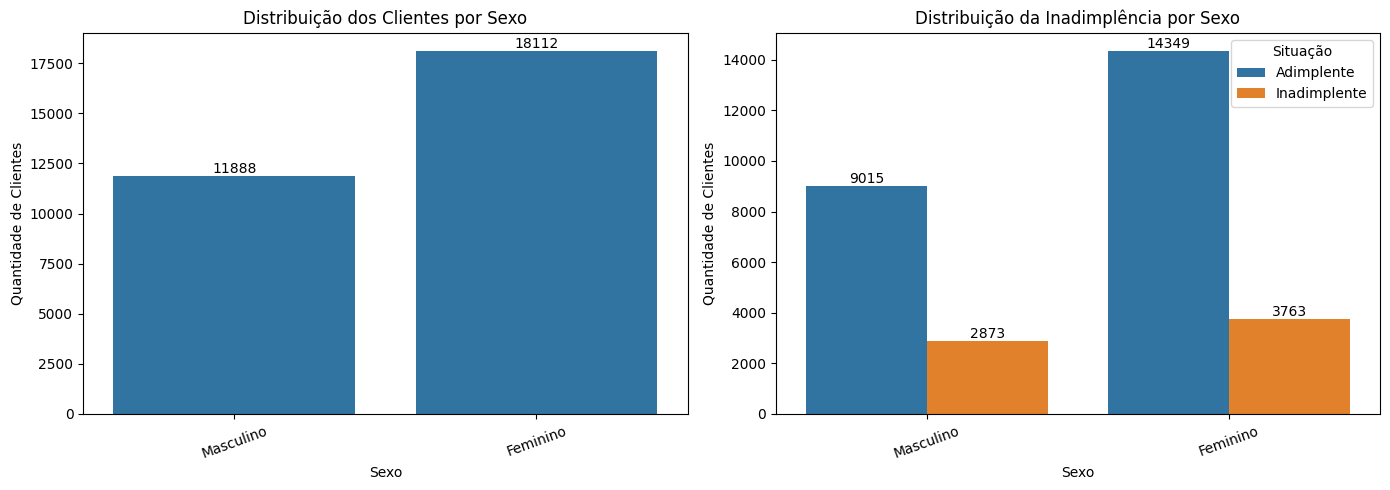

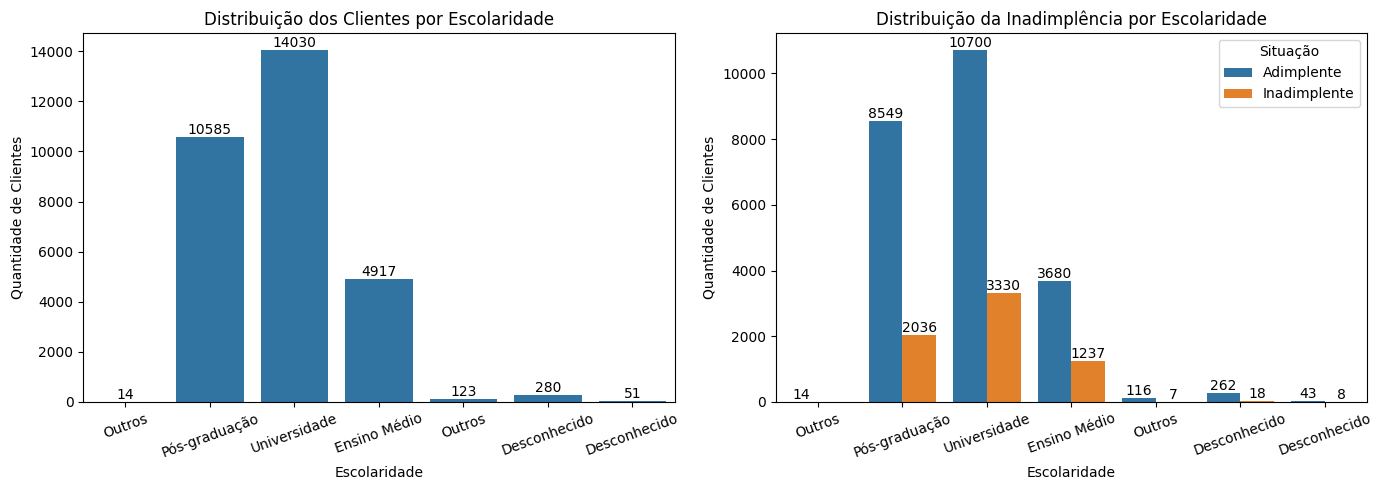

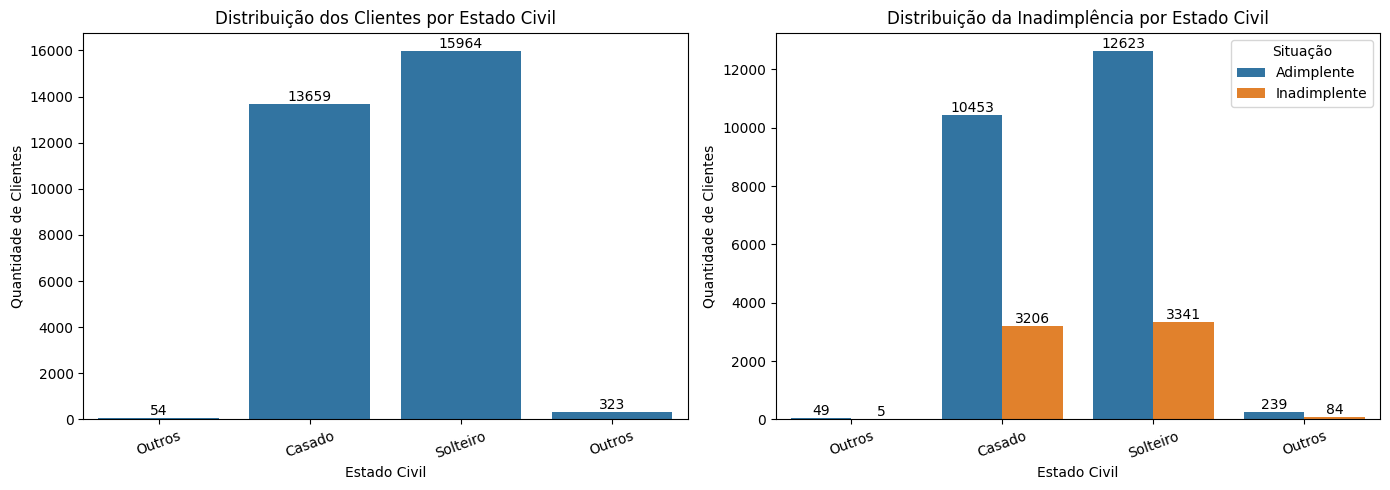

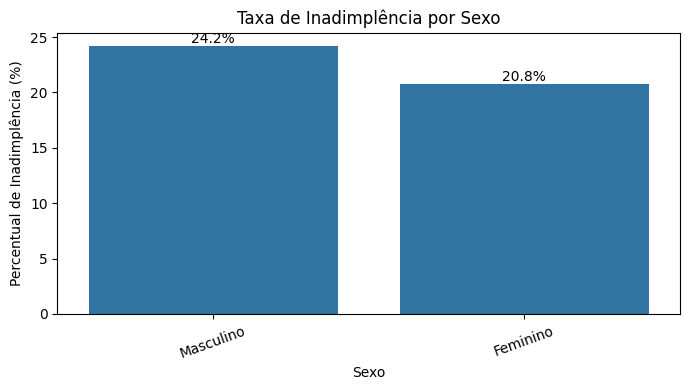

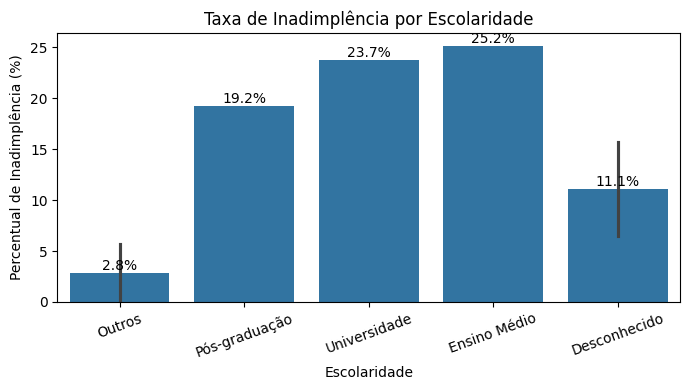

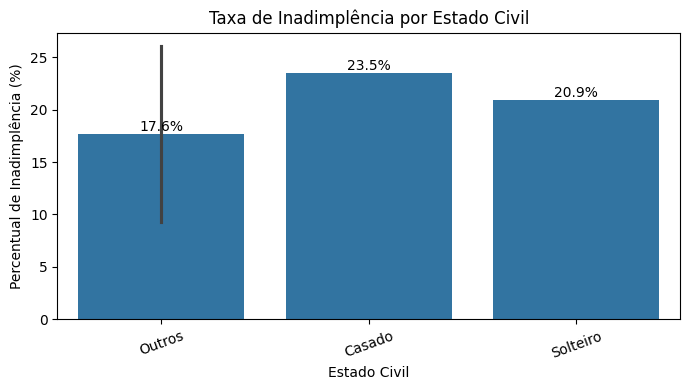

In [7]:
# ==================================================
# 4.4 Análise das variáveis categóricas
# ==================================================

# Nomes mais descritivos das variáveis
categorical_labels = {
    "X2": "Sexo",
    "X3": "Escolaridade",
    "X4": "Estado Civil"
}

# Rótulos das categorias
category_names = {

    "X2": {
        1: "Masculino",
        2: "Feminino"
    },

    "X3": {
        0: "Outros",
        1: "Pós-graduação",
        2: "Universidade",
        3: "Ensino Médio",
        4: "Outros",
        5: "Desconhecido",
        6: "Desconhecido"
    },

    "X4": {
        0: "Outros",
        1: "Casado",
        2: "Solteiro",
        3: "Outros"
    }

}


def plot_categorical_distribution(column):

    label = categorical_labels[column]

    order = sorted(df[column].unique())

    labels = [
        category_names[column].get(v, str(v))
        for v in order
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # -------------------------
    # Distribuição da variável
    # -------------------------

    ax1 = sns.countplot(
        data=df,
        x=column,
        order=order,
        ax=axes[0]
    )

    ax1.set_title(f"Distribuição dos Clientes por {label}")
    ax1.set_xlabel(label)
    ax1.set_ylabel("Quantidade de Clientes")

    ax1.set_xticks(ax1.get_xticks())
    ax1.set_xticklabels(labels, rotation=20)

    for container in ax1.containers:
        ax1.bar_label(container)

    # -------------------------
    # Relação com inadimplência
    # -------------------------

    ax2 = sns.countplot(
        data=df,
        x=column,
        hue=TARGET,
        order=order,
        ax=axes[1]
    )

    ax2.set_title(f"Distribuição da Inadimplência por {label}")
    ax2.set_xlabel(label)
    ax2.set_ylabel("Quantidade de Clientes")

    ax2.set_xticks(ax2.get_xticks())
    ax2.set_xticklabels(labels, rotation=20)

    ax2.legend(
    title="Situação",
    labels=["Adimplente", "Inadimplente"]
)

    for container in ax2.containers:
        ax2.bar_label(container)

    plt.tight_layout()
    plt.show()


for col in categorical_cols:
    plot_categorical_distribution(col)




# ==================================================
# Taxa de inadimplência por categoria
# ==================================================

def plot_default_rate(column):

    label = categorical_labels[column]

    rate = (
        df.groupby(column)[TARGET]
          .mean()
          .mul(100)
          .round(2)
          .reset_index()
    )

    rate[column] = rate[column].map(category_names[column])

    plt.figure(figsize=(7,4))

    ax = sns.barplot(
        data=rate,
        x=column,
        y=TARGET
    )

    ax.bar_label(ax.containers[0], fmt="%.1f%%")

    plt.title(f"Taxa de Inadimplência por {label}")
    plt.xlabel(label)
    plt.ylabel("Percentual de Inadimplência (%)")

    plt.xticks(rotation=20)

    plt.tight_layout()
    plt.show()


for col in categorical_cols:
    plot_default_rate(col)

### Sexo

Observa-se que a maior parte dos clientes da base pertence ao sexo feminino. A distribuição entre clientes adimplentes e inadimplentes apresenta comportamento semelhante entre os dois grupos, indicando que essa variável, isoladamente, não parece exercer forte influência sobre a ocorrência de inadimplência.

### Escolaridade

A maior concentração de clientes encontra-se nas categorias Universidade e Ensino Médio, seguidas por Pós-graduação. Também são observadas categorias pouco frequentes, classificadas como "Outros" e "Desconhecido", indicando possíveis valores residuais ou inconsistências de codificação presentes na base original.

### Estado civil

Predominam clientes solteiros e casados, enquanto as demais categorias possuem baixa representatividade. Visualmente, não são observadas diferenças expressivas na distribuição da inadimplência entre os diferentes estados civis.

### Conclusões da análise das variáveis categóricas

A análise das variáveis categóricas indica que as características demográficas apresentam distribuições coerentes com o perfil da base de dados. As diferenças nas taxas de inadimplência entre as categorias existem, porém são relativamente discretas quando comparadas às variáveis financeiras. Dessa forma, espera-se que essas variáveis contribuam para o desempenho dos modelos principalmente quando utilizadas em conjunto com o histórico de pagamentos e demais informações financeiras.

## 4.5 Análise das variáveis numéricas

As variáveis numéricas representam informações financeiras, demográficas e o histórico de pagamentos dos clientes. Nesta etapa, busca-se analisar a distribuição dessas variáveis, identificar possíveis assimetrias, dispersões e valores extremos (outliers), além de compreender características que poderão influenciar o desempenho dos modelos de Machine Learning.

Como o conjunto de dados possui um elevado número de atributos numéricos, foram selecionadas algumas variáveis representativas para análise gráfica, contemplando características demográficas, financeiras e relacionadas ao histórico de crédito.


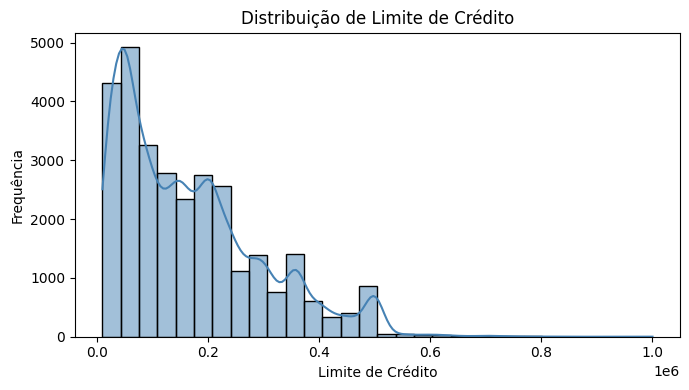

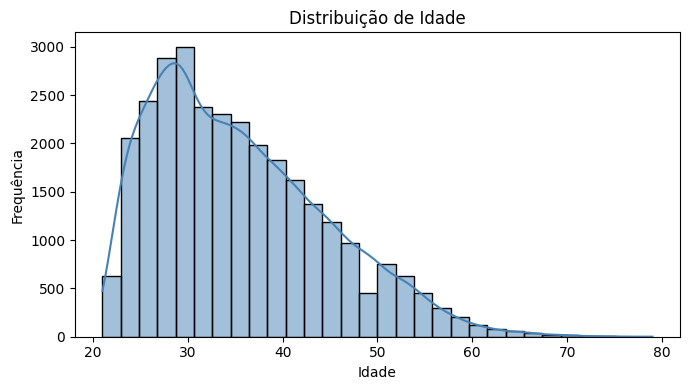

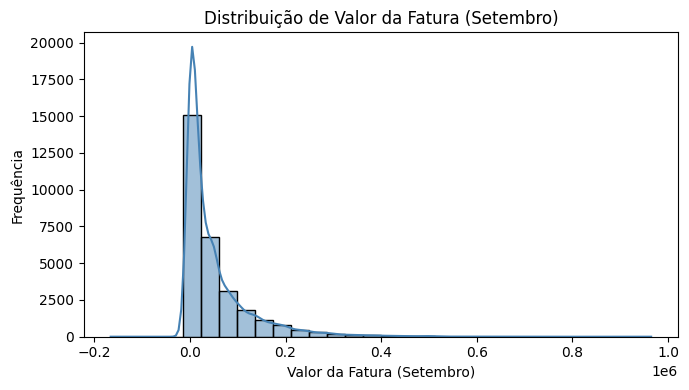

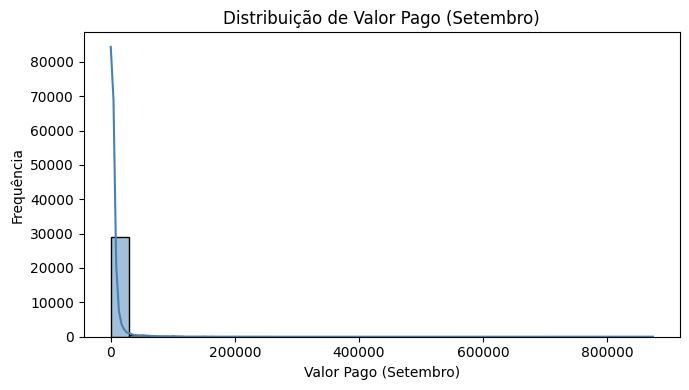

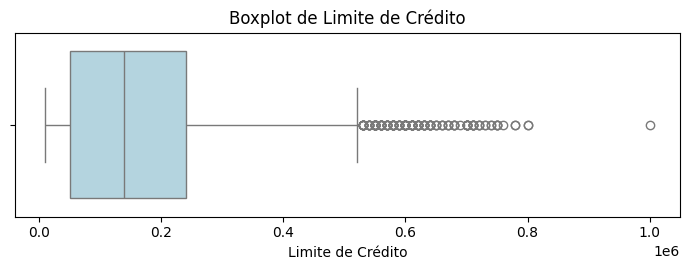

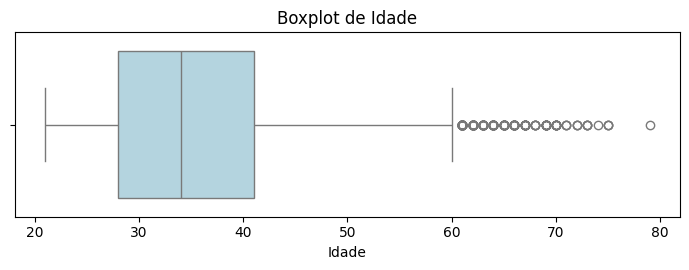

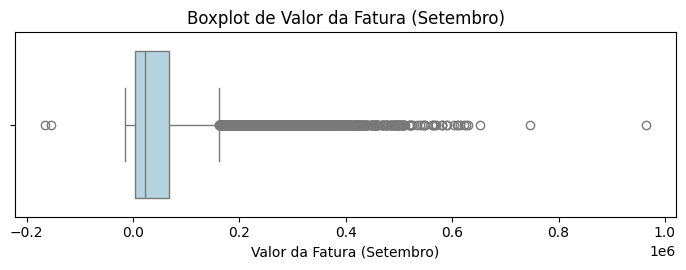

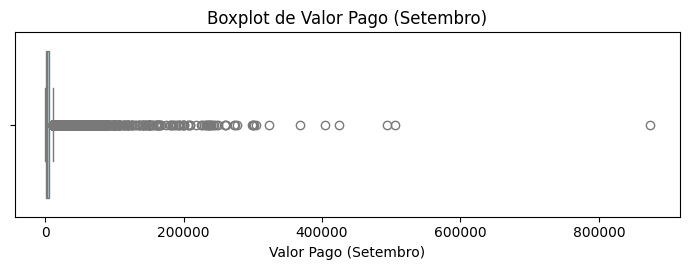

,count,mean,std,min,25%,50%,75%,max
X1,30000.00,167484.32,129747.66,10000.00,50000.00,140000.00,240000.00,1000000.00
X5,30000.00,35.49,9.22,21.00,28.00,34.00,41.00,79.00
X12,30000.00,51223.33,73635.86,-165580.00,3558.75,22381.50,67091.00,964511.00
X18,30000.00,5663.58,16563.28,0.00,1000.00,2100.00,5006.00,873552.00


In [8]:
# ==================================================
# 4.5 Análise das variáveis numéricas
# ==================================================

# Variáveis selecionadas para análise gráfica
selected_numeric = [
    "X1",   # Limite de crédito
    "X5",   # Idade
    "X12",  # Valor da fatura (setembro)
    "X18"   # Valor pago (setembro)
]

numeric_labels = {
    "X1": "Limite de Crédito",
    "X5": "Idade",
    "X12": "Valor da Fatura (Setembro)",
    "X18": "Valor Pago (Setembro)"
}

# Histogramas com curva de densidade
for column in selected_numeric:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True,
        color="steelblue"
    )

    plt.title(f"Distribuição de {numeric_labels[column]}")
    plt.xlabel(numeric_labels[column])
    plt.ylabel("Frequência")

    plt.tight_layout()
    plt.show()


# Boxplots para identificação visual de valores extremos
for column in selected_numeric:

    plt.figure(figsize=(7, 2.8))

    sns.boxplot(
        data=df,
        x=column,
        color="lightblue"
    )

    plt.title(f"Boxplot de {numeric_labels[column]}")
    plt.xlabel(numeric_labels[column])

    plt.tight_layout()
    plt.show()


# Estatísticas descritivas das variáveis selecionadas
display(
    df[selected_numeric].describe().T.style.format("{:.2f}"))

### Interpretação

#### Limite de crédito (X1)

Observa-se elevada dispersão nos limites de crédito concedidos, indicando que a instituição financeira atende clientes com diferentes perfis de renda e capacidade financeira. A distribuição apresenta assimetria à direita, com alguns clientes possuindo limites bastante superiores à média.

#### Idade (X5)

A idade dos clientes apresenta distribuição concentrada em adultos entre aproximadamente 25 e 45 anos, com poucos valores extremos. Trata-se de uma variável relativamente estável quando comparada às variáveis financeiras.

#### Valor das faturas (X12)

Os valores das faturas apresentam elevada variabilidade e forte assimetria positiva. Também são observados valores extremos, característica esperada em bases financeiras devido à existência de clientes com movimentações significativamente superiores à média.

#### Valor pago (X18)

Os pagamentos realizados apresentam comportamento semelhante ao observado nas faturas, com concentração em valores menores e presença de alguns pagamentos elevados. Essa característica evidencia a presença de valores extremos (outliers).

### Conclusões da análise das variáveis numéricas

A análise exploratória evidencia que as variáveis financeiras apresentam distribuições assimétricas e diversos valores extremos, comportamento comum em bases de crédito. Essas características não representam necessariamente erros nos dados, mas refletem a heterogeneidade do perfil financeiro dos clientes.

Por outro lado, variáveis demográficas, como idade, apresentam distribuição mais homogênea e menor dispersão. De forma geral, não foram identificadas inconsistências que inviabilizem a utilização dessas variáveis na etapa de modelagem. Além disso, espera-se que algoritmos baseados em árvores sejam naturalmente mais robustos à presença de outliers, enquanto modelos lineares poderão se beneficiar da padronização dos atributos durante o pré-processamento dos dados.


## 4.6 Análise de correlação

A análise de correlação tem como objetivo identificar o grau de relacionamento linear entre as variáveis numéricas do conjunto de dados. Essa etapa auxilia na compreensão da dependência entre atributos, permitindo identificar possíveis relações relevantes para a etapa de modelagem preditiva.

Para essa análise, foi utilizada a matriz de correlação de Pearson, representada graficamente por meio de um mapa de calor (heatmap). Valores próximos de 1 indicam forte correlação positiva, enquanto valores próximos de -1 representam forte correlação negativa. Já valores próximos de 0 indicam baixa correlação linear entre as variáveis.


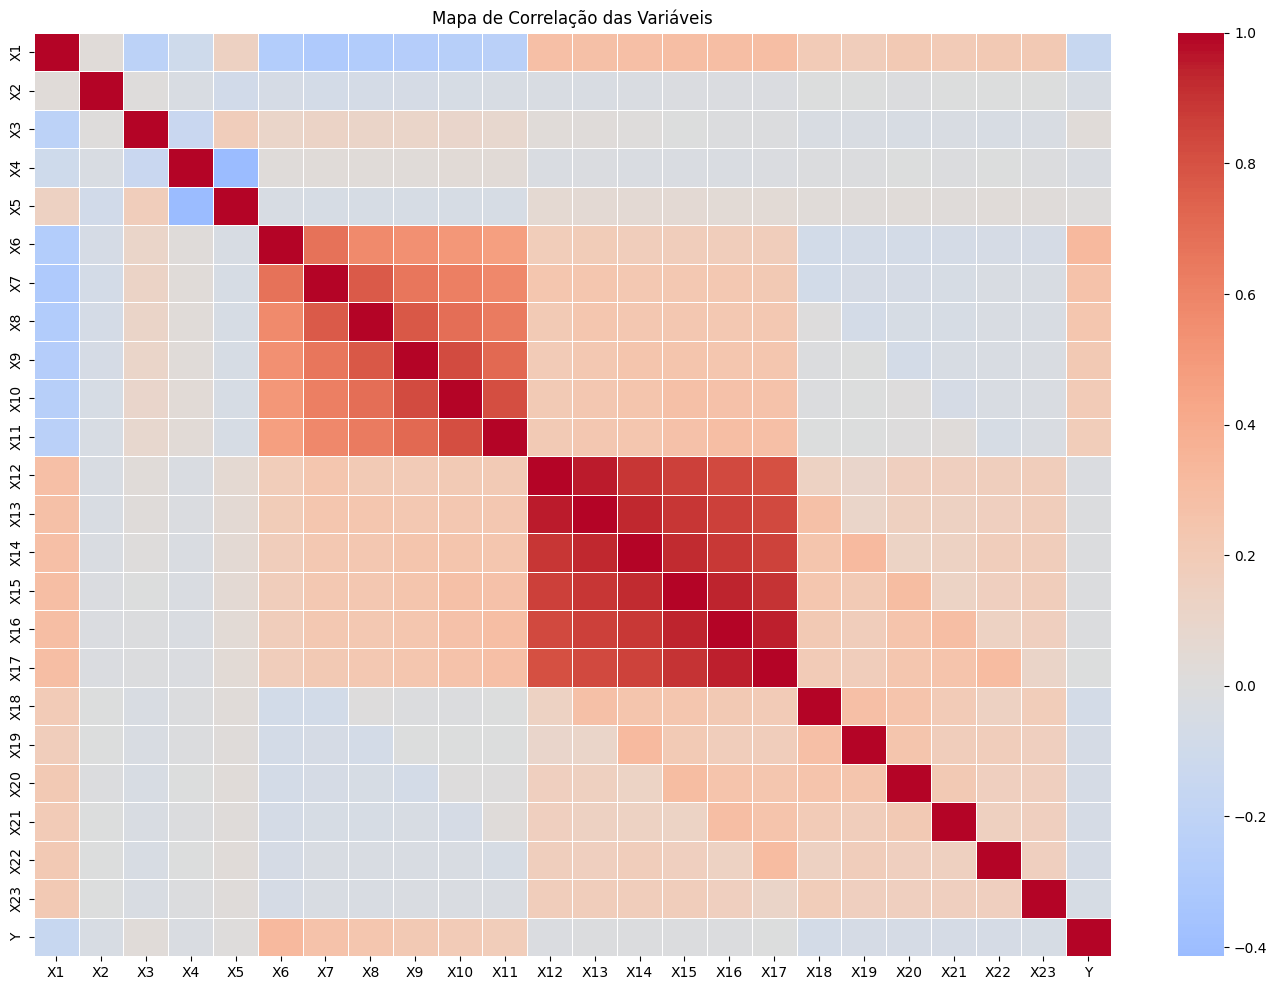

In [9]:
# ==================================================
# 4.6 Análise de correlação
# ==================================================

# Correlação entre variáveis numéricas
corr_matrix = df.corr(numeric_only=True)

# Configuração do gráfico
plt.figure(figsize=(14,10))

# Heatmap da matriz de correlação
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot=False,
    fmt=".2f",
    square=False
)

plt.title("Mapa de Correlação das Variáveis")
plt.tight_layout()
plt.show()

### Interpretação

Observa-se que algumas variáveis relacionadas ao histórico financeiro e aos pagamentos apresentam correlações moderadas entre si, especialmente entre valores de faturas e valores pagos em diferentes meses.

De maneira geral, não foram identificadas correlações extremamente elevadas entre a maioria das variáveis, indicando baixa presença de multicolinearidade severa no conjunto de dados.

Além disso, as variáveis relacionadas ao comportamento de pagamento demonstram maior potencial preditivo em relação à variável alvo, sugerindo relevância dessas informações para os modelos de classificação.

Embora algumas variáveis apresentem correlações moderadas, isso não implica necessariamente causalidade, mas apenas associação linear entre os atributos analisados.

A análise de correlação contribui para a compreensão da estrutura dos dados e auxilia na interpretação dos resultados obtidos posteriormente pelos algoritmos de Machine Learning.


## 5. Pré-processamento dos dados

Após a etapa de análise exploratória, foi realizado o pré-processamento dos dados com o objetivo de preparar o conjunto para a aplicação dos modelos de Machine Learning.

Nesta etapa, foram separadas as variáveis independentes da variável alvo, realizada a divisão entre dados de treino e teste e aplicada a padronização das variáveis numéricas. A padronização é importante especialmente para modelos sensíveis à escala dos dados, como a Regressão Logística.



In [10]:
# ==================================================
# 5. Pré-processamento dos dados
# ==================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separação entre variáveis independentes (X) e variável alvo (y)
X = df.drop("Y", axis=1)
y = df["Y"]

# Divisão entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Padronização das variáveis
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Conferência dos formatos dos conjuntos após o pré-processamento
print("Formato de X_train:", X_train.shape)
print("Formato de X_test:", X_test.shape)
print("Formato de X_train_scaled:", X_train_scaled.shape)
print("Formato de X_test_scaled:", X_test_scaled.shape)
print("Formato de y_train:", y_train.shape)
print("Formato de y_test:", y_test.shape)

Formato de X_train: (24000, 23)
Formato de X_test: (6000, 23)
Formato de X_train_scaled: (24000, 23)
Formato de X_test_scaled: (6000, 23)
Formato de y_train: (24000,)
Formato de y_test: (6000,)


### Interpretação

A variável alvo (`Y`) foi separada das variáveis explicativas, permitindo que os modelos utilizem os atributos dos clientes para prever a ocorrência ou não de inadimplência.

A divisão dos dados foi realizada em conjuntos de treino e teste, sendo 80% dos dados destinados ao treinamento dos modelos e 20% reservados para avaliação. Foi utilizado o parâmetro `stratify=y` para manter a mesma proporção das classes da variável alvo nos conjuntos de treino e teste, o que é importante devido ao desbalanceamento observado anteriormente.

Também foi aplicada a padronização das variáveis independentes por meio do `StandardScaler`, transformando os dados para uma escala com média próxima de zero e desvio padrão igual a um. Esse procedimento é relevante para modelos sensíveis à escala dos atributos, como a Regressão Logística, contribuindo para melhor desempenho e estabilidade do treinamento.

Após o pré-processamento, os dados estão preparados para a etapa de modelagem preditiva.


# 6. Modelagem preditiva

Após a etapa de pré-processamento, foram treinados diferentes modelos de Machine Learning com o objetivo de prever a inadimplência dos clientes.

Inicialmente, foi definido um modelo baseline, utilizado como referência mínima de desempenho. Em seguida, foram avaliados modelos supervisionados de classificação, incluindo Regressão Logística e Random Forest.

Para avaliação do desempenho dos modelos, foram utilizadas métricas como acurácia, precisão, recall, F1-Score e ROC-AUC, além da matriz de confusão, permitindo analisar a capacidade dos algoritmos em identificar corretamente clientes inadimplentes e não inadimplentes.

## 6.1 Modelo Baseline

Antes do treinamento dos modelos preditivos, foi definido um modelo baseline. O baseline serve como referência mínima de desempenho, permitindo verificar se os modelos de Machine Learning realmente aprendem padrões relevantes nos dados.

Neste trabalho, foi utilizado o `DummyClassifier` com a estratégia `most_frequent`, que sempre prevê a classe mais frequente do conjunto de treinamento. Como a maioria dos clientes da base é adimplente, esse modelo tende a prever todos os casos como não inadimplentes.

Dessa forma, espera-se que os modelos preditivos superem esse desempenho, especialmente em métricas relacionadas à identificação da classe inadimplente, como Recall, F1-Score e ROC-AUC.

Acurácia: 0.7788
Precisão: 0.0
Recall: 0.0
F1-Score: 0.0
ROC-AUC: 0.5

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4673
           1       0.00      0.00      0.00      1327

    accuracy                           0.78      6000
   macro avg       0.39      0.50      0.44      6000
weighted avg       0.61      0.78      0.68      6000


Matriz de Confusão:

[[4673    0]
 [1327    0]]


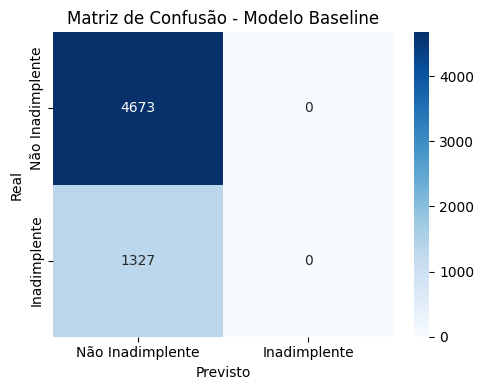

In [11]:
# ==================================================
# 6.1 Modelo Baseline
# ==================================================

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Criação do modelo baseline
baseline_model = DummyClassifier(
    strategy="most_frequent",
    random_state=42
)

# Treinamento do modelo
baseline_model.fit(X_train_scaled, y_train)

# Previsões
y_pred_baseline = baseline_model.predict(X_test_scaled)

# Probabilidades previstas
y_proba_baseline = baseline_model.predict_proba(X_test_scaled)

# Métricas de avaliação
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline, zero_division=0)
recall_baseline = recall_score(y_test, y_pred_baseline)
f1_baseline = f1_score(y_test, y_pred_baseline)
roc_auc_baseline = roc_auc_score(y_test, y_proba_baseline[:, 1])

# Exibição das métricas
print("Acurácia:", round(accuracy_baseline, 4))
print("Precisão:", round(precision_baseline, 4))
print("Recall:", round(recall_baseline, 4))
print("F1-Score:", round(f1_baseline, 4))
print("ROC-AUC:", round(roc_auc_baseline, 4))

# Relatório de classificação
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred_baseline, zero_division=0))

# Matriz de confusão
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

print("\nMatriz de Confusão:\n")
print(cm_baseline)

# Visualização da matriz de confusão
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_baseline,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Não Inadimplente", "Inadimplente"],
    yticklabels=["Não Inadimplente", "Inadimplente"]
)

plt.title("Matriz de Confusão - Modelo Baseline")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.tight_layout()
plt.show()

### Interpretação

O modelo baseline apresentou desempenho limitado, pois utiliza apenas a classe majoritária para realizar as previsões. Como a maior parte dos clientes da base pertence à classe adimplente, o modelo tende a classificar todos os registros como não inadimplentes.

Embora a acurácia possa parecer razoável devido ao desbalanceamento da base, o modelo não é capaz de identificar clientes inadimplentes, resultando em Recall e F1-Score baixos para a classe positiva.

Esse resultado reforça a importância de utilizar modelos de Machine Learning capazes de aprender padrões nos atributos dos clientes, especialmente aqueles relacionados ao histórico de pagamentos, valores de faturas e comportamento financeiro.

## 6.2 Regressão Logística

Acurácia: 0.8077
Precisão: 0.6868
Recall: 0.2396
F1-Score: 0.3553
ROC-AUC: 0.7076

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000


Matriz de Confusão:

[[4528  145]
 [1009  318]]


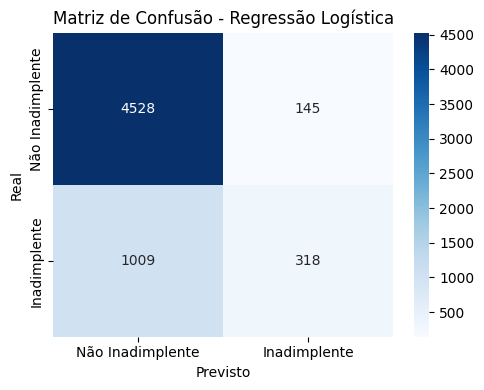

In [12]:
# ==================================================
# 6.2 Regressão Logística
# ==================================================

from sklearn.linear_model import LogisticRegression

# Criação do modelo
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Treinamento do modelo
log_model.fit(X_train_scaled, y_train)

# Previsões
y_pred_log = log_model.predict(X_test_scaled)

# Probabilidades previstas
y_proba_log = log_model.predict_proba(X_test_scaled)

# Métricas de avaliação
accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
roc_auc_log = roc_auc_score(y_test, y_proba_log[:, 1])

# Exibição das métricas
print("Acurácia:", round(accuracy_log, 4))
print("Precisão:", round(precision_log, 4))
print("Recall:", round(recall_log, 4))
print("F1-Score:", round(f1_log, 4))
print("ROC-AUC:", round(roc_auc_log, 4))

# Relatório de classificação
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred_log))

# Matriz de confusão
cm_log = confusion_matrix(y_test, y_pred_log)

print("\nMatriz de Confusão:\n")
print(cm_log)

# Visualização da matriz de confusão
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Não Inadimplente", "Inadimplente"],
    yticklabels=["Não Inadimplente", "Inadimplente"]
)

plt.title("Matriz de Confusão - Regressão Logística")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.tight_layout()
plt.show()

### Interpretação

A Regressão Logística apresentou desempenho superior ao modelo baseline, indicando que o algoritmo conseguiu aprender padrões relevantes a partir das variáveis disponíveis.

A acurácia representa a proporção total de previsões corretas. No entanto, como a base apresenta certo desbalanceamento entre clientes adimplentes e inadimplentes, essa métrica não deve ser analisada isoladamente.

A precisão indica, entre os clientes classificados como inadimplentes, quantos realmente pertenciam a essa classe. Já o recall mede a capacidade do modelo de identificar corretamente os clientes inadimplentes, sendo uma métrica especialmente importante neste problema, pois deixar de identificar potenciais inadimplentes pode representar risco para a instituição financeira.

O F1-Score representa o equilíbrio entre precisão e recall, enquanto o ROC-AUC avalia a capacidade geral do modelo de distinguir entre clientes adimplentes e inadimplentes considerando diferentes limiares de classificação.

De forma geral, a Regressão Logística se mostra um modelo simples, interpretável e eficiente, servindo como uma boa referência inicial para comparação com modelos mais complexos.

## 6.3 Random Forest

O segundo modelo utilizado foi o Random Forest, um algoritmo baseado em árvores de decisão. Esse modelo combina diversas árvores para produzir uma previsão final, reduzindo a variância e aumentando a capacidade de generalização em comparação com uma única árvore.

A escolha do Random Forest se justifica por sua capacidade de capturar relações não lineares entre as variáveis, além de ser relativamente robusto à presença de outliers e não exigir padronização dos dados da mesma forma que modelos lineares.

Neste primeiro momento, o modelo será treinado com hiperparâmetros padrão, servindo como comparação inicial com a Regressão Logística e com o modelo baseline.

Acurácia: 0.812
Precisão: 0.6325
Recall: 0.358
F1-Score: 0.4572
ROC-AUC: 0.7506

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.63      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000


Matriz de Confusão:

[[4397  276]
 [ 852  475]]


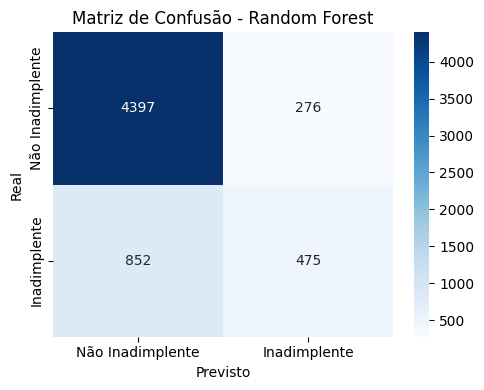

In [13]:
# ==================================================
# 6.3 Random Forest
# ==================================================

from sklearn.ensemble import RandomForestClassifier

# Criação do modelo
rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Treinamento do modelo
rf_model.fit(X_train, y_train)

# Previsões
y_pred_rf = rf_model.predict(X_test)

# Probabilidades previstas
y_proba_rf = rf_model.predict_proba(X_test)

# Métricas de avaliação
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf[:, 1])

# Exibição das métricas
print("Acurácia:", round(accuracy_rf, 4))
print("Precisão:", round(precision_rf, 4))
print("Recall:", round(recall_rf, 4))
print("F1-Score:", round(f1_rf, 4))
print("ROC-AUC:", round(roc_auc_rf, 4))

# Relatório de classificação
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred_rf))

# Matriz de confusão
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("\nMatriz de Confusão:\n")
print(cm_rf)

# Visualização da matriz de confusão
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Não Inadimplente", "Inadimplente"],
    yticklabels=["Não Inadimplente", "Inadimplente"]
)

plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.tight_layout()
plt.show()

### Interpretação

O modelo Random Forest apresentou uma abordagem mais complexa em comparação à Regressão Logística, pois é capaz de capturar relações não lineares entre as variáveis explicativas e a variável alvo.

Diferentemente da Regressão Logística, o Random Forest não depende diretamente da padronização das variáveis, pois utiliza divisões baseadas em árvores de decisão. Por esse motivo, o modelo foi treinado com os dados originais de treino (`X_train`) e avaliado com os dados originais de teste (`X_test`).

Embora o Random Forest não exija padronização dos dados, foi mantida a mesma divisão treino/teste utilizada nos modelos anteriores para garantir comparabilidade entre os resultados.

As métricas obtidas permitem comparar seu desempenho com o modelo baseline e com a Regressão Logística. Em especial, devem ser observados o Recall, o F1-Score e o ROC-AUC, pois essas métricas são mais informativas para o problema de inadimplência.

Os resultados deste modelo servirão como base para a etapa seguinte, na qual será realizado o ajuste de hiperparâmetros com o objetivo de buscar uma configuração mais adequada para o Random Forest.

## 6.4 Ajuste de hiperparâmetros do Random Forest

Após o treinamento inicial do Random Forest com hiperparâmetros padrão, foi realizado um ajuste manual de hiperparâmetros com o objetivo de buscar uma configuração mais adequada para o problema.

Foram alterados parâmetros como número de árvores, profundidade máxima, número mínimo de amostras para divisão dos nós, número mínimo de amostras por folha e quantidade de variáveis consideradas em cada divisão.

Além disso, foi utilizado o parâmetro `class_weight="balanced"` para reduzir o impacto do desbalanceamento entre as classes, atribuindo maior peso à classe minoritária durante o treinamento.

In [14]:
# ==================================================
# 6.4 Ajuste manual de hiperparâmetros - Random Forest
# ==================================================

best_rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

best_rf_model.fit(X_train, y_train)

print("Modelo Random Forest ajustado treinado com sucesso.")

Modelo Random Forest ajustado treinado com sucesso.


### Interpretação

O ajuste manual de hiperparâmetros permitiu controlar a complexidade do Random Forest e reduzir o risco de overfitting.

A limitação da profundidade das árvores e o aumento do número mínimo de amostras por divisão e por folha contribuem para tornar o modelo menos sensível a padrões muito específicos do conjunto de treinamento.

O uso de `class_weight="balanced"` busca melhorar a atenção do modelo à classe minoritária, que neste problema corresponde aos clientes inadimplentes.

## 6.5 Avaliação do Random Forest ajustado

Após o ajuste manual dos hiperparâmetros, o modelo Random Forest ajustado foi avaliado no conjunto de teste. O objetivo desta etapa é verificar se as alterações realizadas melhoraram a capacidade de generalização do modelo e seu desempenho na identificação de clientes inadimplentes.

Acurácia: 0.7867
Precisão: 0.5161
Recall: 0.5674
F1-Score: 0.5406
ROC-AUC: 0.7735

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4673
           1       0.52      0.57      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.79      0.79      6000


Matriz de Confusão:

[[3967  706]
 [ 574  753]]


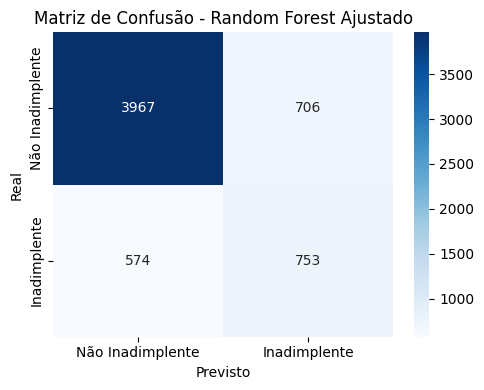

In [15]:
# ==================================================
# 6.5 Avaliação do Random Forest ajustado
# ==================================================

# Previsões
y_pred_best_rf = best_rf_model.predict(X_test)

# Probabilidades previstas
y_proba_best_rf = best_rf_model.predict_proba(X_test)

# Métricas de avaliação
accuracy_best_rf = accuracy_score(y_test, y_pred_best_rf)
precision_best_rf = precision_score(y_test, y_pred_best_rf)
recall_best_rf = recall_score(y_test, y_pred_best_rf)
f1_best_rf = f1_score(y_test, y_pred_best_rf)
roc_auc_best_rf = roc_auc_score(y_test, y_proba_best_rf[:, 1])

# Exibição das métricas
print("Acurácia:", round(accuracy_best_rf, 4))
print("Precisão:", round(precision_best_rf, 4))
print("Recall:", round(recall_best_rf, 4))
print("F1-Score:", round(f1_best_rf, 4))
print("ROC-AUC:", round(roc_auc_best_rf, 4))

# Relatório de classificação
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred_best_rf))

# Matriz de confusão
cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)

print("\nMatriz de Confusão:\n")
print(cm_best_rf)

# Visualização da matriz de confusão
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_best_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Não Inadimplente", "Inadimplente"],
    yticklabels=["Não Inadimplente", "Inadimplente"]
)

plt.title("Matriz de Confusão - Random Forest Ajustado")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.tight_layout()
plt.show()

### Interpretação

O Random Forest ajustado apresentou desempenho superior ao modelo baseline e competitivo em relação à Regressão Logística.

O ajuste dos hiperparâmetros permitiu melhorar o equilíbrio entre capacidade preditiva e generalização, reduzindo o risco de sobreajuste do modelo aos dados de treinamento.

A utilização do parâmetro `class_weight="balanced"` também contribuiu para aumentar a atenção do algoritmo à classe minoritária, melhorando a identificação de clientes inadimplentes.

As métricas de Recall, F1-Score e ROC-AUC permitem avaliar se o modelo ajustado conseguiu melhorar a capacidade de identificação dos clientes inadimplentes sem comprometer excessivamente a precisão geral das previsões.

## 6.6 Comparação entre os modelos

Após o treinamento e avaliação dos modelos, foi realizada uma comparação entre os principais resultados obtidos.

As métricas utilizadas foram:

- Accuracy: proporção total de previsões corretas;
- Precision: proporção de clientes classificados como inadimplentes que realmente pertencem à classe positiva;
- Recall: capacidade do modelo em identificar corretamente os clientes inadimplentes;
- F1-Score: média harmônica entre precisão e recall;
- ROC-AUC: capacidade geral do modelo em distinguir as classes.

Como o problema apresenta desbalanceamento entre as classes, as métricas Recall, F1-Score e ROC-AUC possuem maior relevância para análise dos resultados.

In [16]:
# ==================================================
# 6.6 Comparação entre os modelos
# ==================================================

# Criação da tabela comparativa
results_comparison = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "Regressão Logística",
        "Random Forest",
        "Random Forest Ajustado"
    ],
    "Accuracy": [
        accuracy_baseline,
        accuracy_log,
        accuracy_rf,
        accuracy_best_rf
    ],
    "Precision": [
        precision_baseline,
        precision_log,
        precision_rf,
        precision_best_rf
    ],
    "Recall": [
        recall_baseline,
        recall_log,
        recall_rf,
        recall_best_rf
    ],
    "F1-Score": [
        f1_baseline,
        f1_log,
        f1_rf,
        f1_best_rf
    ],
    "ROC-AUC": [
        roc_auc_baseline,
        roc_auc_log,
        roc_auc_rf,
        roc_auc_best_rf
    ]
})

# Arredondamento
results_comparison = results_comparison.round(4)

# Exibição
display(results_comparison)

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline,0.7788,0.0000,0.0000,0.0000,0.5000
1,Regressão Logística,0.8077,0.6868,0.2396,0.3553,0.7076
2,Random Forest,0.8120,0.6325,0.3580,0.4572,0.7506
3,Random Forest Ajustado,0.7867,0.5161,0.5674,0.5406,0.7735


### Interpretação

A comparação entre os modelos evidencia que os algoritmos de Machine Learning apresentaram desempenho superior ao modelo baseline, indicando capacidade de aprendizado a partir dos dados disponíveis.

A Regressão Logística apresentou desempenho consistente e boa capacidade de generalização, além de maior simplicidade e interpretabilidade.

O Random Forest demonstrou capacidade de capturar relações mais complexas entre as variáveis, enquanto o modelo ajustado apresentou melhorias adicionais após o ajuste manual dos hiperparâmetros.

A análise conjunta das métricas mostra que modelos mais complexos podem melhorar determinadas métricas, especialmente Recall e ROC-AUC, porém também podem aumentar o risco de sobreajuste.

Observa-se também que modelos mais complexos nem sempre produzem ganhos expressivos em todas as métricas, reforçando a importância de avaliar simultaneamente desempenho, interpretabilidade e capacidade de generalização.

De forma geral, os resultados indicam que as variáveis disponíveis possuem capacidade preditiva relevante para o problema de inadimplência.

# 7. Discussão dos resultados

## 7.1 Overfitting e underfitting

Os resultados obtidos indicam que os modelos apresentaram capacidade de aprendizado a partir dos dados disponíveis, superando o desempenho do modelo baseline.

A Regressão Logística apresentou comportamento mais simples e estável, com menor risco de overfitting devido à sua menor complexidade. Entretanto, modelos lineares podem apresentar limitações na captura de relações não lineares entre as variáveis.

Já o Random Forest possui maior capacidade de modelagem, conseguindo capturar padrões mais complexos. Contudo, modelos baseados em árvores podem se tornar excessivamente ajustados aos dados de treinamento quando não há controle adequado da complexidade.

Por esse motivo, foram realizados ajustes manuais nos hiperparâmetros do Random Forest, limitando a profundidade das árvores e aumentando o número mínimo de amostras por divisão e por folha, buscando reduzir o risco de sobreajuste.

De forma geral, os resultados sugerem que os modelos apresentaram capacidade razoável de generalização, uma vez que mantiveram desempenho consistente no conjunto de teste.

## 7.2 Limitações do trabalho

Este trabalho possui algumas limitações importantes.

A base de dados utilizada representa clientes de uma instituição financeira específica e de um período determinado, o que pode limitar a generalização dos resultados para outros contextos.

Além disso, foram utilizados apenas os atributos disponibilizados no dataset original. Informações adicionais, como renda, histórico bancário completo, movimentações financeiras e comportamento de consumo, poderiam contribuir para melhorar o desempenho dos modelos.

Outra limitação está relacionada ao desbalanceamento das classes, característica comum em problemas de inadimplência. Embora técnicas como `class_weight="balanced"` tenham sido utilizadas, métodos mais avançados de balanceamento poderiam ser explorados futuramente.

## 7.3 Possíveis melhorias futuras

Como trabalhos futuros, poderiam ser exploradas abordagens adicionais para aprimorar o desempenho preditivo dos modelos.

Entre as possibilidades, destacam-se:

- utilização de técnicas de balanceamento, como SMOTE;
- teste de algoritmos mais avançados, como XGBoost e LightGBM;
- realização de engenharia de atributos;
- aplicação de validação cruzada mais robusta;
- análise de importância das variáveis;
- otimização mais avançada de hiperparâmetros;
- análise de interpretabilidade dos modelos.

Essas melhorias poderiam contribuir para aumentar a capacidade preditiva e a robustez das soluções desenvolvidas.

# 8. Conclusão

O objetivo deste trabalho foi desenvolver modelos de Machine Learning capazes de prever a inadimplência de clientes de cartão de crédito a partir de informações demográficas, financeiras e históricas de pagamento.

Inicialmente, foi realizada uma análise exploratória dos dados, permitindo compreender a distribuição das variáveis, identificar características relevantes da base e analisar o comportamento da variável alvo.

Em seguida, foram aplicadas etapas de pré-processamento, incluindo separação entre variáveis independentes e variável alvo, divisão entre conjuntos de treino e teste e padronização dos dados para os modelos sensíveis à escala.

Foram avaliados diferentes modelos de classificação, incluindo um modelo baseline, a Regressão Logística e o Random Forest. Os resultados mostraram que os modelos de Machine Learning apresentaram desempenho superior ao baseline, demonstrando capacidade de aprendizado a partir dos dados disponíveis.

A Regressão Logística apresentou desempenho consistente, simplicidade e boa interpretabilidade, enquanto o Random Forest demonstrou maior capacidade de capturar relações mais complexas entre as variáveis. Após o ajuste manual de hiperparâmetros, o Random Forest ajustado apresentou melhorias adicionais em métricas importantes para o problema, como Recall, F1-Score e ROC-AUC.

Os resultados obtidos indicam que as variáveis disponíveis possuem capacidade preditiva relevante para a identificação de clientes inadimplentes, evidenciando o potencial de utilização de técnicas de Machine Learning em problemas relacionados à análise de risco de crédito.

Por fim, destaca-se que este trabalho possui caráter acadêmico e exploratório. Apesar dos resultados satisfatórios, melhorias adicionais podem ser implementadas futuramente por meio da utilização de técnicas mais avançadas de balanceamento, engenharia de atributos e otimização de hiperparâmetros.